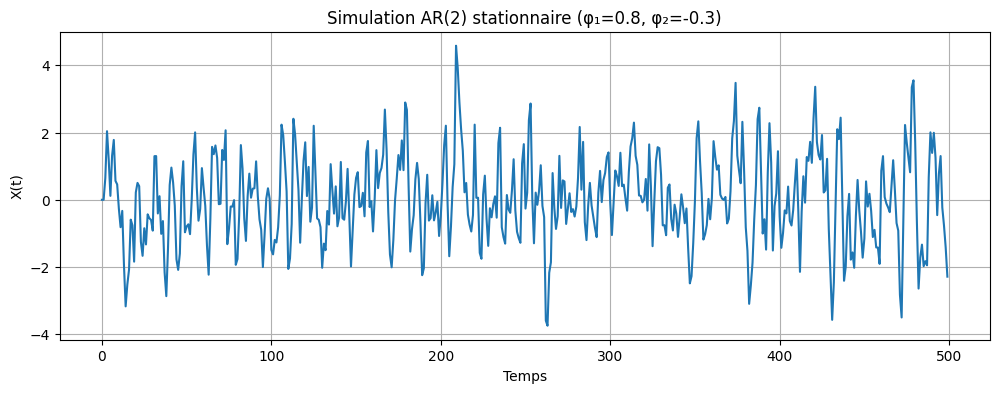

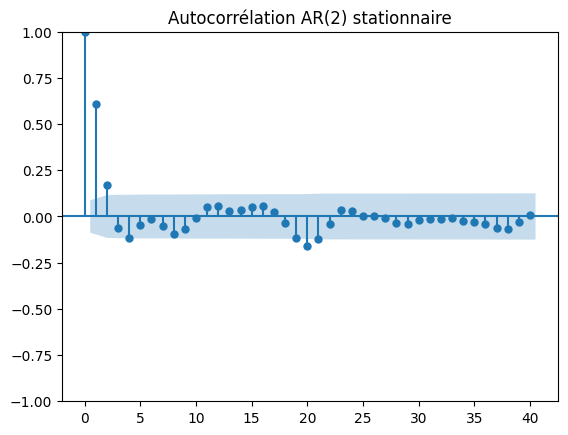

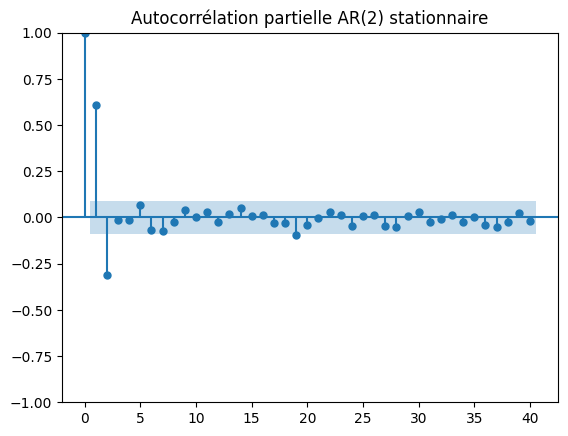

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Simulation
np.random.seed(42)
n = 500
eps = np.random.normal(0, 1, n)
X = np.zeros(n)
phi1, phi2 = 0.8, -0.3

for t in range(2, n):
    X[t] = phi1 * X[t-1] + phi2 * X[t-2] + eps[t]

# Tracé de la série
plt.figure(figsize=(12, 4))
plt.plot(X)
plt.title("Simulation AR(2) stationnaire (φ₁=0.8, φ₂=-0.3)")
plt.xlabel("Temps")
plt.ylabel("X(t)")
plt.grid(True)
plt.show()

# ACF
plot_acf(X, lags=40, alpha=0.05, title="Autocorrélation AR(2) stationnaire")
plt.show()

# PACF
plot_pacf(X, lags=40, alpha=0.05, title="Autocorrélation partielle AR(2) stationnaire")
plt.show()

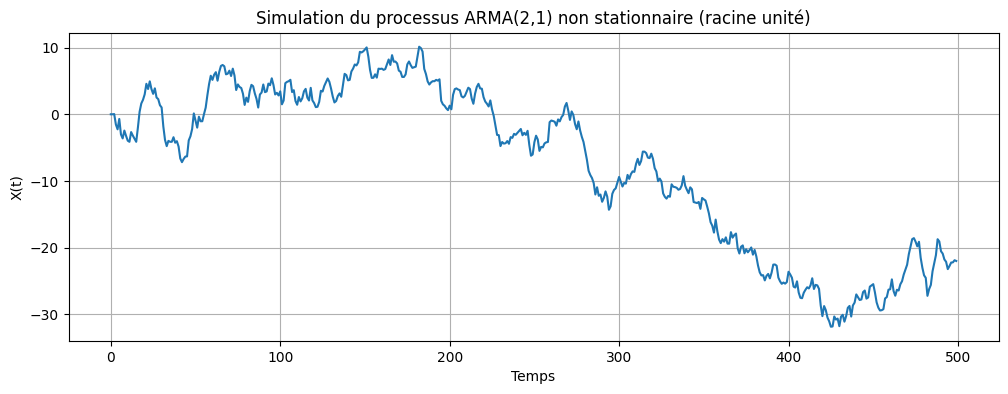

<Figure size 1200x400 with 0 Axes>

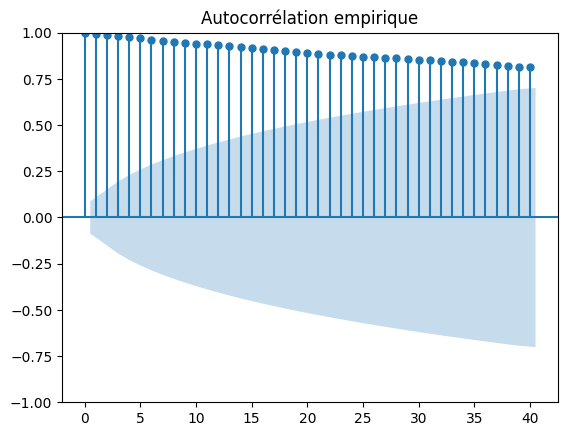

<Figure size 1200x400 with 0 Axes>

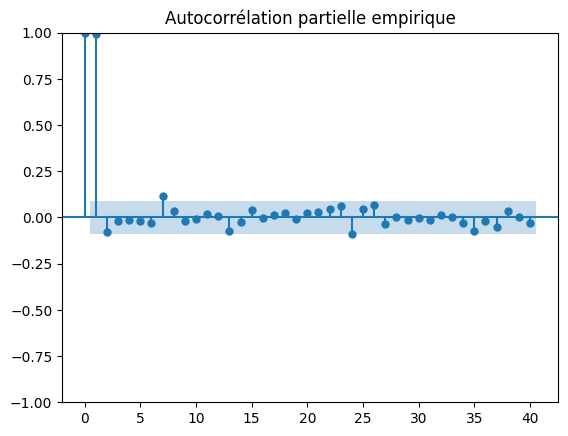

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Simulation du processus
np.random.seed(123)
n = 500
eps = np.random.normal(0, 1, n)
X = np.zeros(n)

for t in range(2, n):
    X[t] = (4/3)*X[t-1] - (1/3)*X[t-2] + eps[t] - 0.25*eps[t-1]

# Tracé de la série
plt.figure(figsize=(12, 4))
plt.plot(X)
plt.title("Simulation du processus ARMA(2,1) non stationnaire (racine unité)")
plt.xlabel("Temps")
plt.ylabel("X(t)")
plt.grid(True)
plt.show()

# Calcul et tracé de l'ACF
plt.figure(figsize=(12, 4))
plot_acf(X, lags=40, alpha=0.05, title="Autocorrélation empirique")
plt.show()

# Tracé de la PACF (facultatif)
plt.figure(figsize=(12, 4))
plot_pacf(X, lags=40, alpha=0.05, title="Autocorrélation partielle empirique")
plt.show()

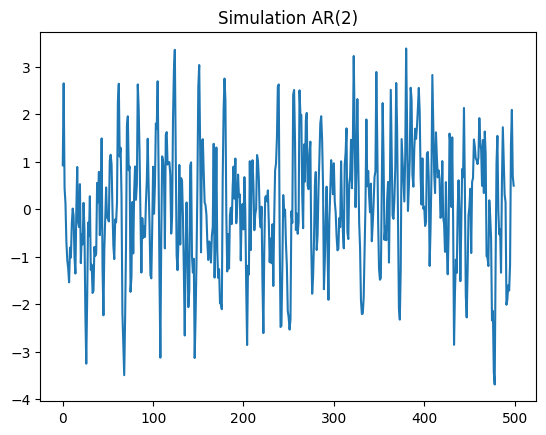

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Simulation d'un AR(2) stationnaire : Xt = 0.8 Xt-1 -0.3 Xt-2 + eps
ar = [1, -0.8, 0.3]   # 1 - 0.8B + 0.3B^2  (attention au signe)
ma = [1]              # pas de partie MA
AR_object = ArmaProcess(ar, ma)
X = AR_object.generate_sample(nsample=500, scale=1)

plt.plot(X)
plt.title("Simulation AR(2)")
plt.show()

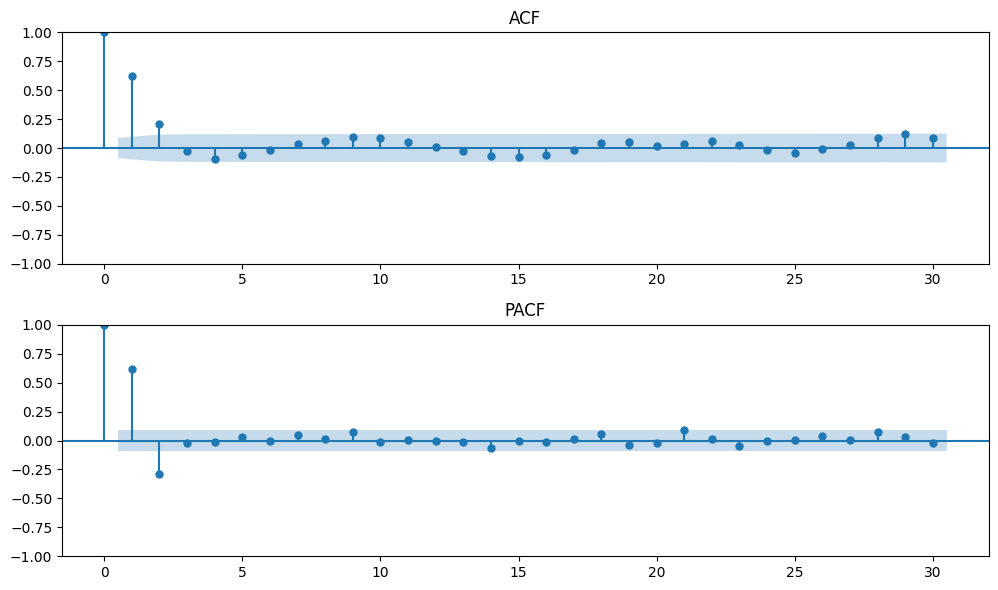

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(X, ax=ax1, lags=30, title="ACF")
plot_pacf(X, ax=ax2, lags=30, title="PACF")
plt.tight_layout()
plt.show()

In [7]:
result = adfuller(X)
print(f"ADF p-value : {result[1]:.4f}")  # p < 0.05 → stationnaire

ADF p-value : 0.0000


In [8]:
model = ARIMA(X, order=(2,0,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  500
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -698.091
Date:                Thu, 19 Mar 2026   AIC                           1404.183
Time:                        22:23:20   BIC                           1421.041
Sample:                             0   HQIC                          1410.798
                                - 500                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0624      0.089      0.700      0.484      -0.112       0.237
ar.L1          0.7950      0.043     18.291      0.000       0.710       0.880
ar.L2         -0.2864      0.044     -6.548      0.0

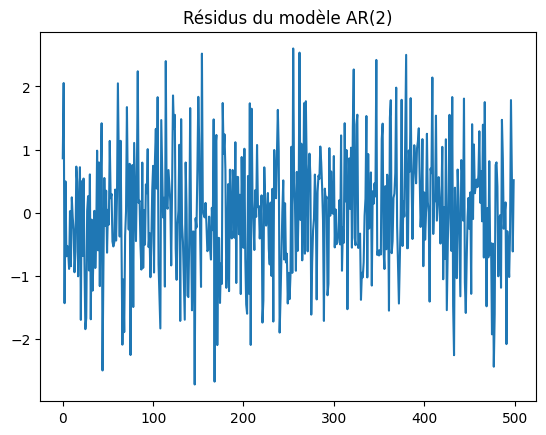

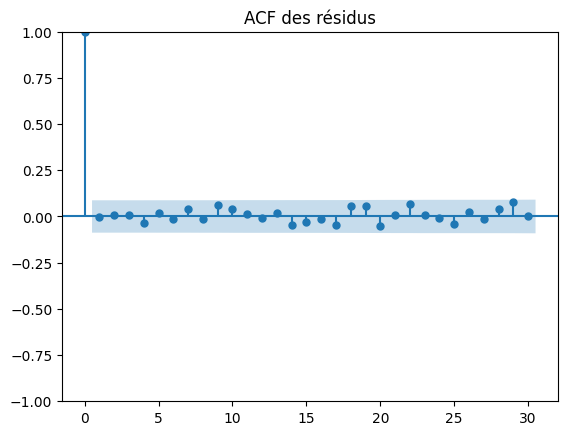

      lb_stat  lb_pvalue
10   4.833324   0.902030
20  12.658403   0.891555


In [9]:
residuals = model_fit.resid

# Tracé des résidus
plt.plot(residuals)
plt.title("Résidus du modèle AR(2)")
plt.show()

# ACF des résidus
plot_acf(residuals, lags=30)
plt.title("ACF des résidus")
plt.show()

# Test de Ljung-Box (absence d'autocorrélation)
lb_test = acorr_ljungbox(residuals, lags=[10,20], return_df=True)
print(lb_test)

In [10]:
forecast = model_fit.forecast(steps=10)
print(forecast)

[0.22810284 0.06969324 0.02073991 0.02719418 0.04634653 0.05972387
 0.06487312 0.06513519 0.06386868 0.06278676]


In [13]:
#!pip install pmdarima
from pmdarima import auto_arima
auto_model = auto_arima(X, seasonal=False, stepwise=True, trace=True)
print(auto_model.order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1406.497, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1683.022, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1443.074, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1446.529, Time=0.02 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1408.183, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1404.519, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1409.456, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1402.675, Time=0.03 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1404.530, Time=0.04 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1406.512, Time=0.15 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1404.183, Time=0.04 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 0.454 seconds
(2, 0, 0)
